Number of features: 13

Features:
['EURUSD_change_lag_1', 'EURUSD_change_lag_2', 'EURUSD_change_lag_3', 'EURUSD_change_lag_4', 'EURUSD_change_lag_5', 'EURUSD_change_lag_6', 'EURUSD_change_lag_7', 'EURUSD_change_lag_8', 'EURUSD_change_lag_9', 'EURUSD_change_lag_10', 'diff2Y_lag_1', 'diff10Y_lag_1', 'diffCPI_lag_1']

Training samples: 8002
Testing samples : 2001

RANDOM FOREST RESULTS (predicting change)
RMSE = 0.004523
MAE  = 0.003060

NAIVE MODEL
RMSE = 0.004516
MAE  = 0.003044

FEATURE IMPORTANCE
                 Feature  Importance
6    EURUSD_change_lag_7    0.137874
0    EURUSD_change_lag_1    0.127694
5    EURUSD_change_lag_6    0.101319
1    EURUSD_change_lag_2    0.076906
3    EURUSD_change_lag_4    0.074448
9   EURUSD_change_lag_10    0.073434
2    EURUSD_change_lag_3    0.071553
8    EURUSD_change_lag_9    0.070010
11         diff10Y_lag_1    0.067523
7    EURUSD_change_lag_8    0.067295
10          diff2Y_lag_1    0.060661
4    EURUSD_change_lag_5    0.047440
12         diffC

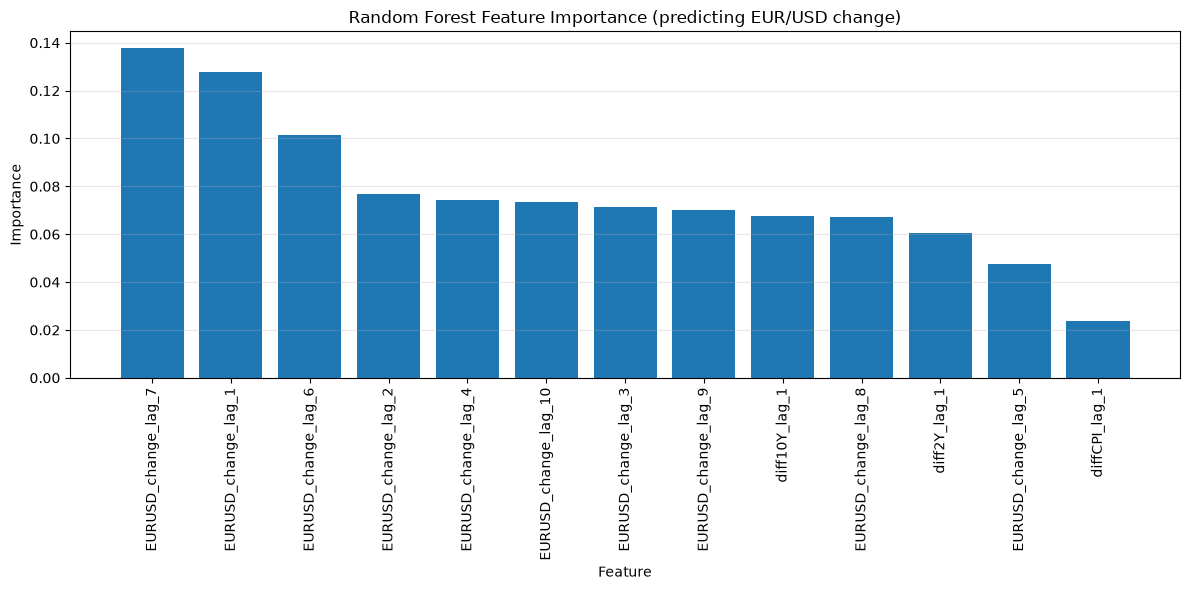

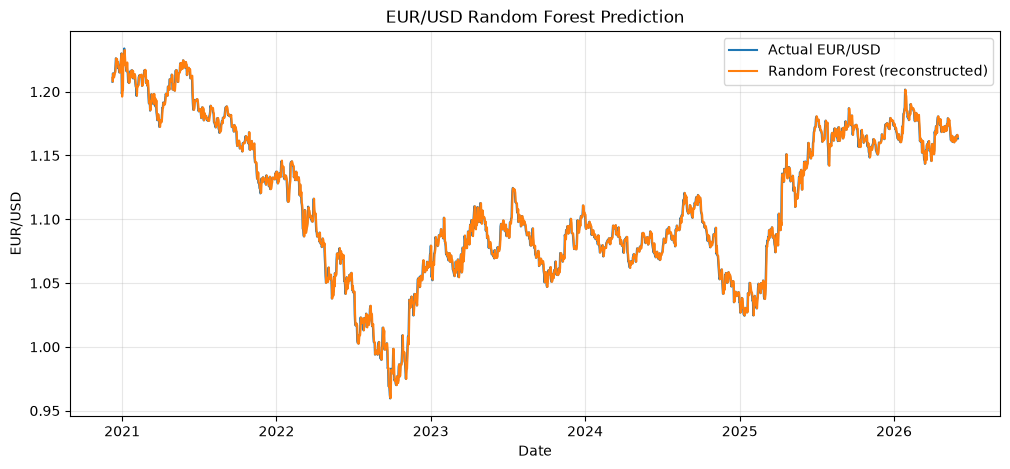

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)



# ucitavanje

DATA_PATH = "data/sve.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


# pravljenje parametara

df["diff2Y"] = df["USA2Y"] - df["GER2Y"]
df["diff10Y"] = df["USA10Y"] - df["GER10Y"]
df["diffCPI"] = df["CPI"] - df["HICP"]


# 
df["EURUSD_change"] = df["EURUSD"].diff()


# ============================================================
# 4. CREATE LAGGED FEATURES
# ============================================================

N_LAGS = 10

data = pd.DataFrame()

# Past EUR/USD changes (not past levels)
for lag in range(1, N_LAGS + 1):
    data[f"EURUSD_change_lag_{lag}"] = df["EURUSD_change"].shift(lag)


# Economic variables
economic_variables = [
    "diff2Y",
    "diff10Y",
    "diffCPI"
]

for variable in economic_variables:
    data[f"{variable}_lag_1"] = df[variable].shift(1)


# Targets (keep both: the change to train on, the level to score with)
data["EURUSD_change"] = df["EURUSD_change"]
data["EURUSD"] = df["EURUSD"]

# Remove rows with NaN caused by lagging / differencing
data = data.dropna().reset_index(drop=True)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

X = data.drop(columns=["EURUSD_change", "EURUSD"])
y = data["EURUSD_change"]

print("Number of features:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# Do not shuffle time-series data.

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 7. RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 8. TRAIN
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 9. PREDICT THE CHANGE, RECONSTRUCT THE PRICE LEVEL
# ============================================================

pred_change = model.predict(X_test)

# predicted price_t = actual price_{t-1} + predicted change
prev_price = data["EURUSD"].iloc[split - 1: len(data) - 1].values
prediction = prev_price + pred_change
actual_price = data["EURUSD"].iloc[split:].values


# ============================================================
# 10. EVALUATION (on price level, so it's comparable to before)
# ============================================================

rmse = np.sqrt(
    mean_squared_error(actual_price, prediction)
)

mae = mean_absolute_error(
    actual_price,
    prediction
)

print("\n==============================")
print("RANDOM FOREST RESULTS (predicting change)")
print("==============================")

print(f"RMSE = {rmse:.6f}")
print(f"MAE  = {mae:.6f}")


# ============================================================
# 11. NAIVE BASELINE
# ============================================================

# Predict EUR/USD using previous day's EUR/USD (no change)

naive_prediction = prev_price

naive_rmse = np.sqrt(
    mean_squared_error(actual_price, naive_prediction)
)

naive_mae = mean_absolute_error(
    actual_price,
    naive_prediction
)

print("\n==============================")
print("NAIVE MODEL")
print("==============================")

print(f"RMSE = {naive_rmse:.6f}")
print(f"MAE  = {naive_mae:.6f}")


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance_df)


# ============================================================
# 13. PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.title("Random Forest Feature Importance (predicting EUR/USD change)")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 14. PLOT ACTUAL VS PREDICTION (reconstructed price level)
# ============================================================

# data row 0 corresponds to df row (len(df) - len(data)) -- computed
# dynamically rather than assumed as N_LAGS, since .diff() adds one
# more leading NaN on top of the N_LAGS lag columns.
dropped_rows = len(df) - len(data)
test_dates = df["Date"].iloc[dropped_rows + split:]

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_price,
    label="Actual EUR/USD"
)

plt.plot(
    test_dates,
    prediction,
    label="Random Forest (reconstructed)"
)

plt.title("EUR/USD Random Forest Prediction")
plt.xlabel("Date")
plt.ylabel("EUR/USD")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Text(0.5, 1.0, 'EUR/USD Prediction for the last 500 days')

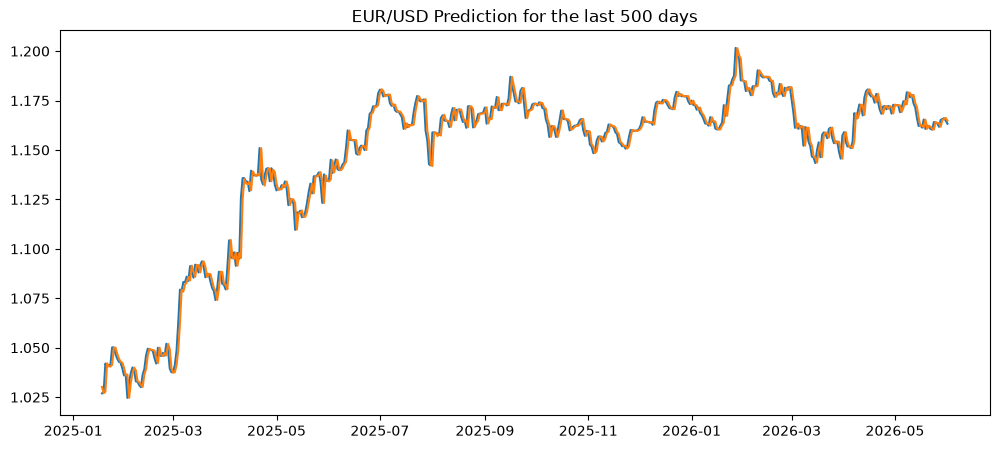

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_dates[-500::],
    actual_price[-500::],
    label="Actual EUR/USD"
)

plt.plot(
    test_dates[-500::],
    prediction[-500::],
    label="Random Forest (reconstructed)"
)
plt.title("EUR/USD Prediction for the last 500 days")


Data after creating lags:
   EURUSD_change_lag_1  EURUSD_change_lag_2  EURUSD_change_lag_3  \
0              -0.0075               0.0000               0.0000   
1               0.0049              -0.0075               0.0000   
2               0.0124               0.0049              -0.0075   
3               0.0000               0.0124               0.0049   
4              -0.0118               0.0000               0.0124   

   EURUSD_change_lag_4  EURUSD_change_lag_5  EURUSD_change_lag_6  \
0              -0.0128               0.0083              -0.0130   
1               0.0000              -0.0128               0.0083   
2               0.0000               0.0000              -0.0128   
3              -0.0075               0.0000               0.0000   
4               0.0049              -0.0075               0.0000   

   EURUSD_change_lag_7  EURUSD_change_lag_8  EURUSD_change_lag_9  \
0              -0.0057               0.0132               0.0000   
1              -0.0

,Model,RMSE,MAE,R²,Adjusted R²
0,Naive,0.004516,0.003044,0.994102,0.994099
1,Random Forest,0.004524,0.003062,0.994082,0.994052


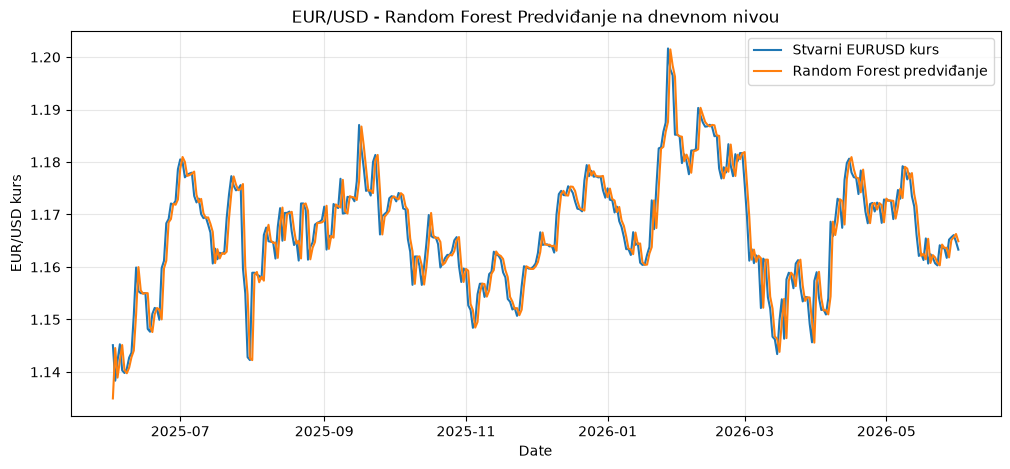


Feature importance:
                Feature  Importance
6   EURUSD_change_lag_7    0.151269
0   EURUSD_change_lag_1    0.149676
5   EURUSD_change_lag_6    0.114425
1   EURUSD_change_lag_2    0.095560
3   EURUSD_change_lag_4    0.089643
2   EURUSD_change_lag_3    0.088845
9  EURUSD_change_lag_10    0.087827
7   EURUSD_change_lag_8    0.084367
8   EURUSD_change_lag_9    0.079078
4   EURUSD_change_lag_5    0.059311


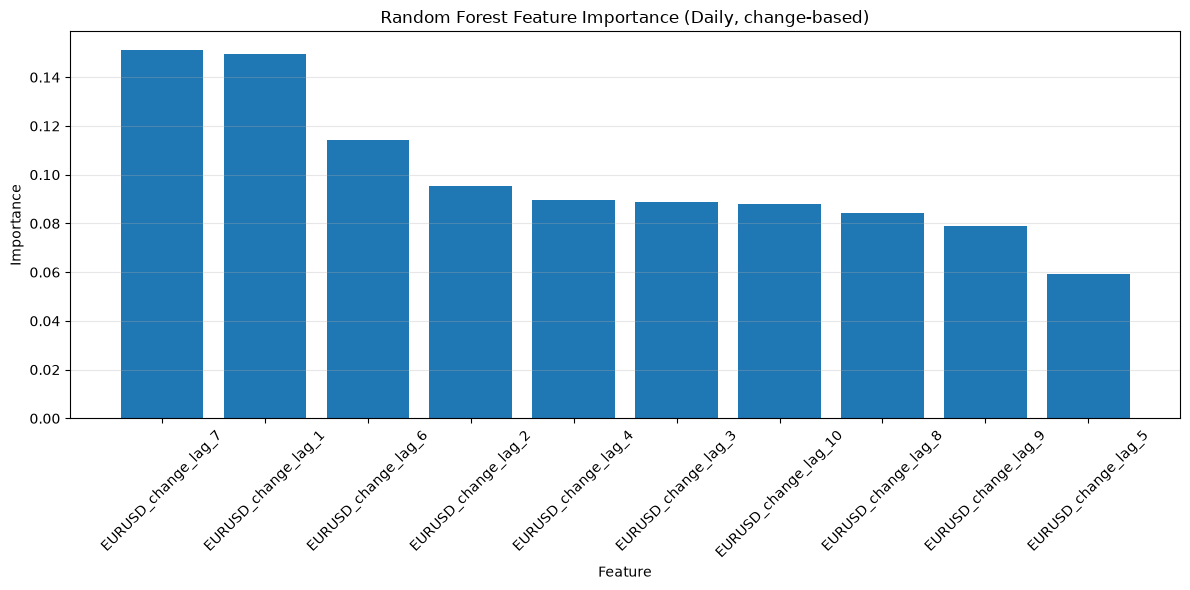

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# 1. LOAD DATA
# ============================================================
name = "eurusd"
DATA_PATH = f"data/{name}.csv"

df = pd.read_csv(DATA_PATH)

# Convert Date to datetime, sort, and set it as the index.
# .loc["...":"..."] only slices by date if Date IS the index --
# as a plain column it silently falls back to positional slicing,
# which is why the old cutoff wasn't actually filtering by date.
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.set_index("Date")

df = df.loc[: "2026-06-01"]

# Resample to daily (last observation of each day, Friday close)
#df = df.resample("W-FRI").last()


# ============================================================
# 2. TARGET: PREDICT THE CHANGE, NOT THE LEVEL
# ============================================================
# A Random Forest can only output values it saw in the training
# target range -- it can't extrapolate past the highest/lowest
# {name.upper()} level it was trained on. That's why the price-level
# version went flat once {name.upper()} broke into new highs.
# Predicting the day-over-week CHANGE removes that ceiling: the
# final price is reconstructed as (previous actual price + predicted
# change), and the previous actual price is real data, not something
# the model has to output -- so the reconstructed price is free to
# go anywhere.

df[f"{name.upper()}_change"] = df["Close"].diff()


# ============================================================
# 3. CREATE LAGGED FEATURES
# ============================================================

N_LAGS = 10

data = pd.DataFrame()

for lag in range(1, N_LAGS + 1):
    data[f"{name.upper()}_change_lag_{lag}"] = df[f"{name.upper()}_change"].shift(lag)

# Targets (keep both: the change to train on, the level to score with)
data[f"{name.upper()}_change"] = df[f"{name.upper()}_change"]
data[f"{name.upper()}"] = df["Close"]

# Keep the (now daily) dates aligned with each row before dropping NaNs
data["Date"] = df.index

# Remove rows containing NaN values
data = data.dropna().reset_index(drop=True)

print("\nData after creating lags:")
print(data.head())


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop(columns=[f"{name.upper()}_change", f"{name.upper()}", "Date"])
y_target = data[f"{name.upper()}_change"]

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# Do NOT randomly shuffle time-series data.

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y_target.iloc[:split]
y_test  = y_target.iloc[split:]

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 6. CREATE RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 7. TRAIN
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 8. PREDICT THE CHANGE, RECONSTRUCT THE PRICE LEVEL
# ============================================================

pred_change = model.predict(X_test)

# predicted price_t = actual price_{t-1} + predicted change
prev_price = data[f"{name.upper()}"].iloc[split - 1: len(data) - 1].values
prediction = prev_price + pred_change
actual_price = data[f"{name.upper()}"].iloc[split:].values


# ============================================================
# 9. EVALUATION
# ============================================================

rmse = np.sqrt(
    mean_squared_error(actual_price, prediction)
)

mae = mean_absolute_error(
    actual_price,
    prediction
)

# R²
r2 = r2_score(
    actual_price,
    prediction
)

# Adjusted R²
n = len(actual_price)
k = X_test.shape[1]   # broj prediktora/features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("\n==============================")
print("RANDOM FOREST RESULTS (daily, predicting change)")
print("==============================")

print(f"RMSE         = {rmse:.6f}")
print(f"MAE          = {mae:.6f}")
print(f"R²           = {r2:.6f}")
print(f"Adjusted R²  = {adjusted_r2:.6f}")


# ============================================================
# 10. NAIVE BASELINE
# ============================================================

naive_prediction = prev_price

naive_rmse = np.sqrt(
    mean_squared_error(actual_price, naive_prediction)
)

naive_mae = mean_absolute_error(
    actual_price,
    naive_prediction
)

# R² za naive model
naive_r2 = r2_score(
    actual_price,
    naive_prediction
)

# Adjusted R² za naive model
# Naive model koristi jednu prethodnu vrednost kao prediktor.
naive_k = 1

naive_adjusted_r2 = (
    1
    - (1 - naive_r2)
    * (n - 1)
    / (n - naive_k - 1)
)

print("\n==============================")
print("NAIVE MODEL (daily)")
print("==============================")

print(f"RMSE         = {naive_rmse:.6f}")
print(f"MAE          = {naive_mae:.6f}")
print(f"R²           = {naive_r2:.6f}")
print(f"Adjusted R²  = {naive_adjusted_r2:.6f}")

# ============================================================
# 10.5 MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Naive",
        "Random Forest"
    ],
    "RMSE": [
        naive_rmse,
        rmse
    ],
    "MAE": [
        naive_mae,
        mae
    ],
    "R²": [
        naive_r2,
        r2
    ],
    "Adjusted R²": [
        naive_adjusted_r2,
        adjusted_r2
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

display(results)


# ============================================================
# 11. PLOT ACTUAL VS PREDICTED
# ============================================================

presek = -365

test_dates = data["Date"].iloc[split:]

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates[presek:],
    actual_price[presek:],
    label=f"Stvarni {name.upper()} kurs"
)

plt.plot(
    test_dates[presek:],
    prediction[presek:],
    label="Random Forest predviđanje"
)

plt.title(f"{name.upper()[:3]}/{name.upper()[3:]} - Random Forest Predviđanje na dnevnom nivou")
plt.xlabel("Date")
plt.ylabel(f"{name.upper()[:3]}/{name.upper()[3:]} kurs")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature importance:")
print(importance_df)


# ============================================================
# 13. PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance (Daily, change-based)")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

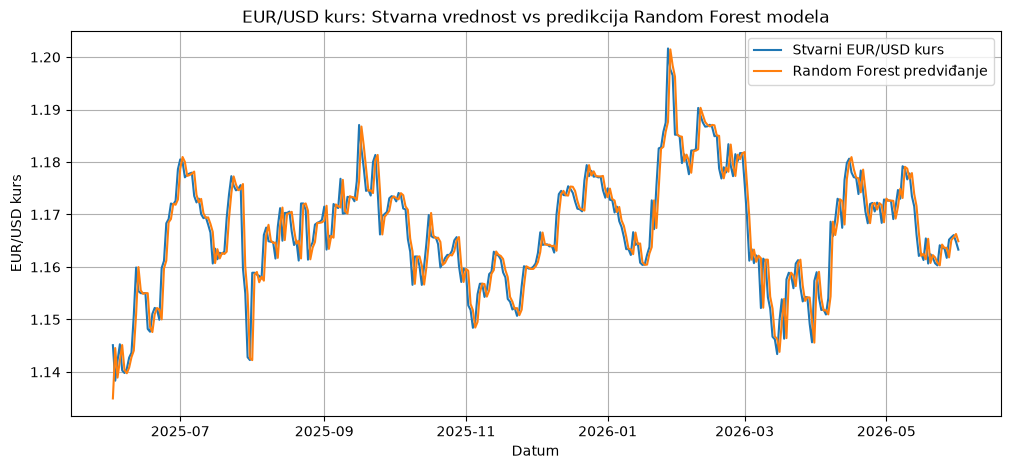

In [5]:
presek = -365

test_dates = data["Date"].iloc[split:]

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates[presek:],
    actual_price[presek:],
    label=f"Stvarni {name.upper()[:3]}/{name.upper()[3:]} kurs"
)

plt.plot(
    test_dates[presek:],
    prediction[presek:],
    label="Random Forest predviđanje"
)

plt.title(f"{name.upper()[:3]}/{name.upper()[3:]} kurs: Stvarna vrednost vs predikcija Random Forest modela")
plt.xlabel("Datum")
plt.ylabel(f"{name.upper()[:3]}/{name.upper()[3:]} kurs")

plt.legend()
plt.grid()

plt.show()